# `rad_transfer` tutorial

This notebook teaches the slab-radiative-transfer tools in `empylib.rad_transfer`, from a fast Beer-Lambert estimate to the adding-doubling method with either sphere-derived or user-supplied scattering inputs.

**Learning goals**

- compute slab transmission with the Beer-Lambert approximation
- switch to `adm_sphere` when particle scattering matters
- use `adm` directly when you already know absorption, scattering, and phase behavior

**Notebook design**

- every runnable cell calls the public `empylib` API directly
- parameter meanings are explained in markdown and in short inline comments
- outputs are inspected in the same notebook so you can see what each function returns
- the core path is offline-first; internet-backed examples live in clearly marked optional appendices

In [2]:
from pathlib import Path
import os
import sys

current = Path.cwd().resolve()
for candidate in (current, *current.parents):
    if (candidate / "empylib").exists() and (candidate / "docs").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the EMPI Lib repository root.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (7, 3)

import empylib.miescattering as mie
import empylib.rad_transfer as rt

## Beer-Lambert slab with embedded particles

**Functions used**

- rt.T_beer_lambert

**Problem we are solving**

Start with the quickest estimate: absorption and single-pass losses in a particle-filled slab, including interface effects through the slab boundaries.

**Parameter guide for this example**

- `Nh`: refractive index of the host medium
- `Np`: particle refractive index
- `D`: particle diameter in micrometers
- `fv`: particle volume fraction
- `tfilm`: slab thickness in micrometers
- `theta`: incidence angle in degrees for this API
- `Nup` and `Ndw`: refractive index above and below the slab

**Outputs to inspect**

- a DataFrame with total and separated transmission / reflection channels

,Rtot,Ttot,Tspec,Tdif
Wavelength (µm),,,,
0.400,0.038823,1.947046e-16,1.289093e-283,1.947046e-16
0.405,0.038823,1.195831e-16,5.019581e-286,1.195831e-16
0.410,0.038823,8.044800e-17,6.683544e-287,8.044800e-17
0.415,0.038823,6.752583e-17,5.803749e-286,6.752583e-17
0.420,0.038823,7.827911e-17,3.578083e-283,7.827911e-17


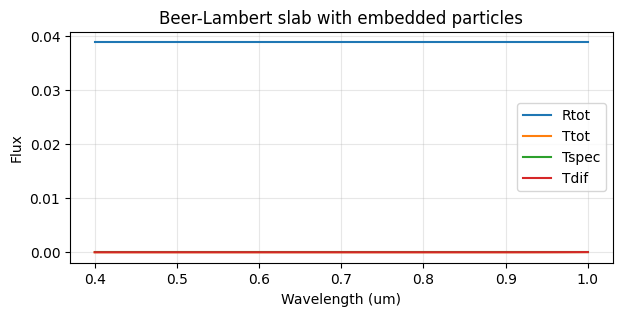

In [3]:
lam = np.linspace(0.40, 1.00, 121)
nh = 1.49 + 0.00j + 0 * lam
npart = 2.35 + 0.02j + 0 * lam

beer_result = rt.T_beer_lambert(
    lam,
    nh,
    npart,
    0.30,    # particle diameter in micrometers
    fv=0.06, # particle volume fraction
    tfilm=0.50,
    theta=8.0, # angle in degrees
    Nup=1.00,
    Ndw=1.52,
)

display(beer_result.head())

fig, ax = plt.subplots()
for col in beer_result.columns:
    ax.plot(beer_result.index, beer_result[col], label=col)
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Flux")
ax.set_title("Beer-Lambert slab with embedded particles")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The DataFrame columns separate total, specular, and diffuse flux channels depending on what the approximation can predict. This is the fastest workflow when you mainly want a first estimate of slab transmittance.

**Common pitfalls**

- This API expects `theta` in degrees, not radians
- Beer-Lambert is an approximation; once multiple scattering matters, it can become too optimistic

**Try this next**

- Increase `fv` or `tfilm` and compare how strongly transmission collapses
- Switch to `adm_sphere` for the same slab to see the effect of multiple scattering

## Adding-doubling for spherical particles

**Functions used**

- rt.adm_sphere

**Problem we are solving**

When the slab is scattering strongly, the adding-doubling method is more appropriate. `adm_sphere` keeps the convenient particle specification and computes the internal transport quantities for you.

**Parameter guide for this example**

- `dependent_scatt=False`: disable structure-factor corrections in this example
- `effective_medium=True`: include the host/particle effective-medium correction for the slab index
- `use_phase_fun=False`: use the asymmetry factor instead of the full phase function in this example

**Outputs to inspect**

- an adding-doubling result DataFrame with total, specular, and diffuse components

,Rtot,Ttot,Rspec,Tspec,Rdif,Tdif
Wavelength (µm),,,,,,
0.400,0.097129,4.442595e-61,0.044573,2.502919e-278,0.052556,4.442595e-61
0.405,0.097833,2.036746e-61,0.044573,1.872210e-279,0.053261,2.036746e-61
0.410,0.098634,1.020407e-61,0.044573,1.939164e-279,0.054062,1.020407e-61
0.415,0.099594,6.897397e-62,0.044573,4.321424e-278,0.055022,6.897397e-62
0.420,0.100767,7.427279e-62,0.044573,2.195253e-275,0.056195,7.427279e-62


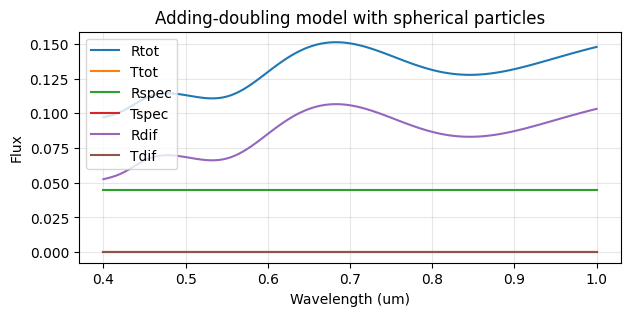

In [4]:
adm_sphere_result = rt.adm_sphere(
    lam,
    nh,
    npart,
    0.30,
    fv=0.06,
    tfilm=0.50,
    Nup=1.00,
    Ndw=1.52,
    dependent_scatt=False,
    effective_medium=True,
    use_phase_fun=False,
)

display(adm_sphere_result.head())

fig, ax = plt.subplots()
for col in adm_sphere_result.columns:
    ax.plot(adm_sphere_result.index, adm_sphere_result[col], label=col)
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Flux")
ax.set_title("Adding-doubling model with spherical particles")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

Compared with Beer-Lambert, adding-doubling can redistribute energy between specular and diffuse channels through multiple scattering. This is usually the safer model when particle scattering is not negligible.

**Common pitfalls**

- Adding-doubling is more informative, but it also asks you to think harder about the phase-function approximation
- Keep the host, particle, and film inputs consistent with the physical slab you want to model

**Try this next**

- Enable `use_phase_fun=True` and compare the result with the asymmetry-factor approximation
- Turn on `dependent_scatt=True` for a denser medium

## Direct adding-doubling from user-supplied scattering data

**Functions used**

- rt.adm

**Problem we are solving**

Sometimes you already know the absorption coefficient, scattering coefficient, and either an asymmetry factor or a full phase function. In that case you can bypass the sphere model and call `adm` directly.

**Parameter guide for this example**

- `k_sca` and `k_abs`: scattering and absorption coefficients on the wavelength grid
- `gcos`: asymmetry factor, used in the first direct ADM call
- `phase_fun`: full phase function, used in the second direct ADM call
- `Nh`: refractive index of the slab host medium

**Outputs to inspect**

- `adm_from_g` and `adm_from_phase`: two DataFrames that differ only in how the angular information is supplied

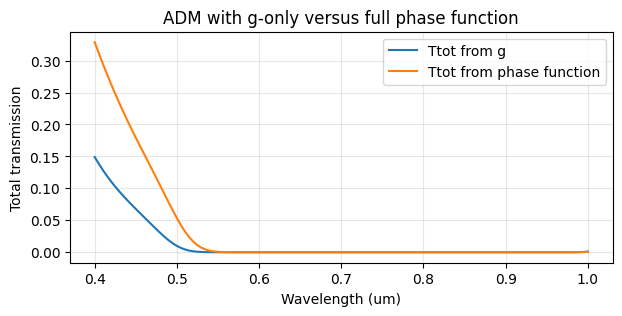

In [5]:
k_sca = 0.8 * np.exp(-((lam - 0.65) / 0.16) ** 2)
k_abs = 0.2 * np.exp(-((lam - 0.82) / 0.12) ** 2)
gcos = np.clip(0.2 + 0.6 * (lam - lam.min()) / (lam.max() - lam.min()), 0, 0.95)

adm_from_g = rt.adm(
    lam,
    tfilm=0.30,
    k_sca=k_sca,
    k_abs=k_abs,
    Nh=nh,
    gcos=gcos,  # asymmetry factor description of angular scattering
    Nup=1.00,
    Ndw=1.52,
)

phase_fun = mie.phase_scatt_HG(
    lam,
    gcos=np.full(lam.size, 0.75),
    qsca=np.ones_like(lam),
    theta=np.linspace(0.0, np.pi, 181),
)

adm_from_phase = rt.adm(
    lam,
    tfilm=0.30,
    k_sca=k_sca,
    k_abs=k_abs,
    Nh=nh,
    phase_fun=phase_fun,  # full angle-resolved phase function
    Nup=1.00,
    Ndw=1.52,
)

fig, ax = plt.subplots()
ax.plot(lam, adm_from_g["Ttot"], label="Ttot from g")
ax.plot(lam, adm_from_phase["Ttot"], label="Ttot from phase function")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Total transmission")
ax.set_title("ADM with g-only versus full phase function")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

This direct API is useful when your scattering information comes from measurement, another solver, or a custom phase-function model. The comparison shows how much difference there is between a compact `g` description and a fully resolved angular phase function.

**Common pitfalls**

- Pass either `gcos` or `phase_fun` according to the model you want; do not confuse a scalar asymmetry factor with a full phase function
- The transport coefficients must be sampled on the same wavelength grid as the refractive-index inputs

**Try this next**

- Replace the HG phase function with one built from `miescattering.phase_scatt_ensemble`
- Inspect `Rdif` and `Tdif` in addition to `Ttot` to understand where the changes come from